<h1>Train — EfficientNet-B0</h1>

Trains and evaluates EfficientNet-B0 using the tuned hyperparameters from `ARCH_HYPERPARAMS["efficientnet_b0"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Fisantekraal
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1814 | Val: 441 | Test: 252


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["efficientnet_b0"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"EfficientNet-B0: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

EfficientNet-B0: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's classifier is nn.Sequential(Dropout, Linear) — swap out
# just the Linear layer for our (optionally deeper) classifier head, same
# as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[1].in_features
model.classifier[1] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[EfficientNet-B0] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[EfficientNet-B0] Epoch   1/100 | LR: 1.00e-04 | train loss 1.1987 acc 0.533 | val loss 0.7437 acc 0.703 *


[EfficientNet-B0] Epoch   2/100 | LR: 1.00e-04 | train loss 0.6837 acc 0.710 | val loss 0.4932 acc 0.780 *


[EfficientNet-B0] Epoch   3/100 | LR: 1.00e-04 | train loss 0.5488 acc 0.755 | val loss 0.5084 acc 0.787


[EfficientNet-B0] Epoch   4/100 | LR: 1.00e-04 | train loss 0.4505 acc 0.798 | val loss 0.4318 acc 0.816 *


...

[EfficientNet-B0] Epoch  17/100 | LR: 1.00e-05 | train loss 0.1203 acc 0.948 | val loss 0.3855 acc 0.873


[EfficientNet-B0] Epoch  18/100 | LR: 1.00e-05 | train loss 0.1105 acc 0.954 | val loss 0.3882 acc 0.875


[EfficientNet-B0] Epoch  19/100 | LR: 1.00e-05 | train loss 0.1150 acc 0.949 | val loss 0.3852 acc 0.891


[EfficientNet-B0] Epoch  20/100 | LR: 1.00e-05 | train loss 0.1323 acc 0.939 | val loss 0.3815 acc 0.887


[EfficientNet-B0] Epoch  21/100 | LR: 1.00e-05 | train loss 0.1222 acc 0.945 | val loss 0.3940 acc 0.873

[EfficientNet-B0] No val loss improvement for 10 epochs — stopping early at epoch 21.

[EfficientNet-B0] Restored best checkpoint (val loss = 0.3633)


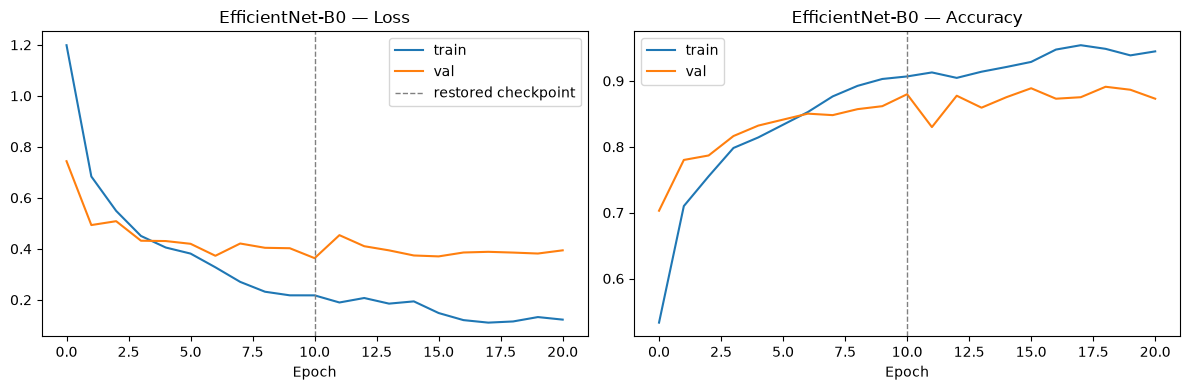

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "EfficientNet-B0", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "EfficientNet-B0")

## Evaluate on the test set

[EfficientNet-B0] Test accuracy: 0.762


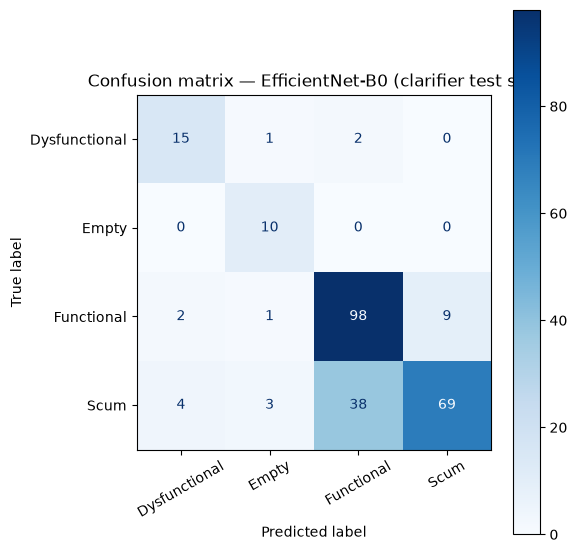

               precision    recall  f1-score   support

Dysfunctional      0.714     0.833     0.769        18
        Empty      0.667     1.000     0.800        10
   Functional      0.710     0.891     0.790       110
         Scum      0.885     0.605     0.719       114

     accuracy                          0.762       252
    macro avg      0.744     0.832     0.770       252
 weighted avg      0.788     0.762     0.757       252



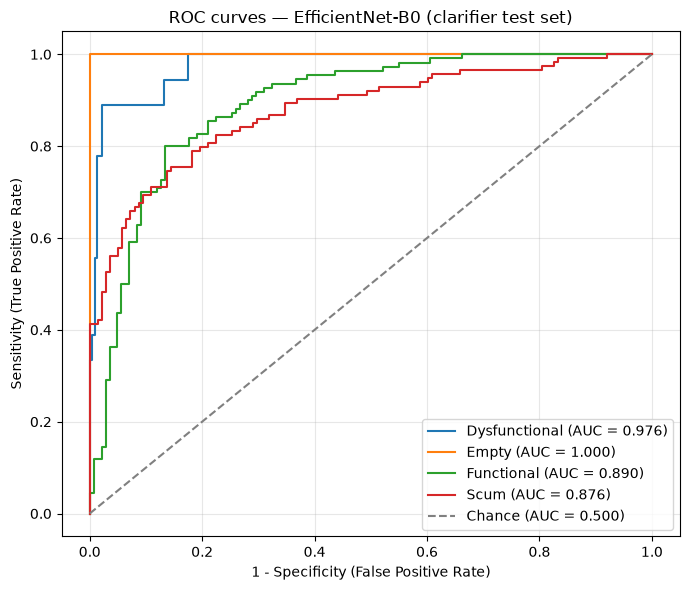

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.976
  Empty          : 1.000
  Functional     : 0.890
  Scum           : 0.876

Mean AUC (over 4/4 classes with test examples): 0.936


(np.float64(0.7619047619047619),
 {'Dysfunctional': 0.9760208926875593,
  'Empty': 1.0,
  'Functional': 0.8902688860435339,
  'Scum': 0.8763030765319094})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "EfficientNet-B0", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("EfficientNet-B0", "efficientnet_b0")

Saved results to ../results/results_clarifier_efficientnet_b0_Fisantekraal.pkl
Saved model weights to ../models/clarifier_efficientnet_b0_cnn.pt
